---
title: "Blog 04: Analysis of Pennsylvania Crash Data"
description: "placeholder"
author: "Daniel Park"
date: "2/25/2026"
categories:
  - car crashes
  - data stories
  - data visualization
---

Road crashes are a major public safety issue in large cities, where dense traffic, complex road networks, and pedestrian activity interact in unpredictable ways. Philadelphia has long struggled with dangerous road corridors, particularly wide arterial roads where high vehicle speeds mix with local traffic and pedestrian activity.

Some roads in the city have developed a particularly strong reputation for danger. Roosevelt Boulevard, for example, is frequently cited as one of the most dangerous roads in Philadelphia. According to an article by the Philadelphia Tribune, "between 2011 and 2015, about 13 percent of the city’s traffic fatalities occurred on the 16-mile stretch of Roosevelt Boulevard running from Hunting Park to just beyond the city line in Bensalem. During that period the corridor saw more than 60 deaths and roughly 4,700 injuries, with pedestrians accounting for about one-third of those killed on the 12-lane road." Other analyses of PennDOT crash data have also noted that Philadelphia contains a disproportionate share of Pennsylvania’s deadliest road segments. Additionally, according to WarperNewman, sections of Broad Street frequently appear among the most dangerous in the state.

In this post, I analyze nearly two decades of Pennsylvania Department of Transportation (PennDOT) crash records to better understand patterns in Philadelphia traffic collisions. Using geospatial analysis, I first examine how crashes are distributed across the city and how crash severity changes over time and by time of day. I will then take a closer look at several major corridors, including Roosevelt Boulevard, Broad Street, to investigate whether the patterns in the data support their reputation as some of the most dangerous roads in the region.

In response to persistent fatalities on Roosevelt Boulevard, the city has introduced automated speed enforcement cameras along sections of the corridor in an effort to reduce speeding and improve safety. Early reports suggest that these cameras have significantly reduced fatal crashes, raising an important question: how much can targeted policy interventions influence road safety outcomes?

Sources:

[Philly’s riskiest and deadliest roads are concentrated in Black and Brown neighborhoods](https://www.phillytrib.com/news/local_news/philly-s-riskiest-deadliest-roads-in-black-and-brown-neighborhoods/article_1d03b88e-2edf-5cbd-9f42-dd5eddf8fedf.html)

[5 of the Most Dangerous Roads in the U.S.](https://www.hg.org/legal-articles/5-of-the-most-dangerous-roads-in-the-u-s--32057)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

from shapely.geometry import Point

In [2]:
crash_data = pd.read_csv("data/PDOT_crash_data_2005_2024.csv", low_memory=False)
philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")
data_dictionary = pd.read_csv('data/data_dictionary.csv')
div_gdf = gpd.read_file("data/Political_Divisions.geojson")
streets = gpd.read_file("data/Street_Centerline.geojson")

## Spatial distribution of crashes across Philadelphia

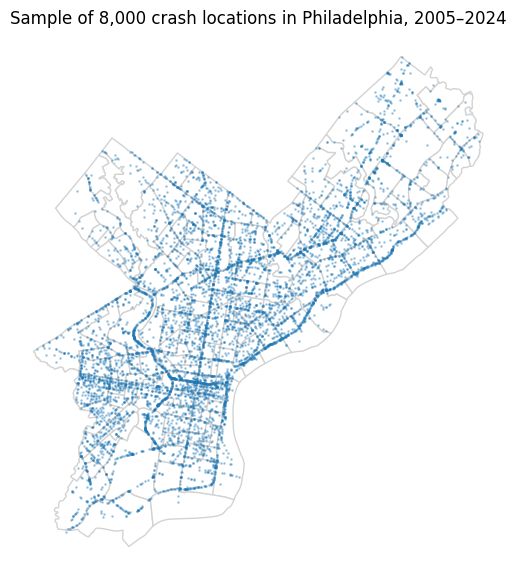

In [3]:
phil_filter = crash_data['COUNTY'] == 67

phil_crashes = crash_data[phil_filter].copy()

# remove rows without decimal coordinates
phil_crashes = phil_crashes.dropna(subset=['DEC_LATITUDE','DEC_LONGITUDE'])

phil_crashes.shape

geom = gpd.points_from_xy(phil_crashes['DEC_LONGITUDE'], phil_crashes['DEC_LATITUDE'])
phil_crashes_gdf = gpd.GeoDataFrame(phil_crashes, geometry=geom).set_crs('EPSG:4326')

philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")

base = philly_zip.plot(color='white', edgecolor='lightgray', figsize=(7,7))
phil_crashes_gdf.sample(8000).plot(ax=base, markersize=1, alpha=0.3)
base.axis('off')
plt.title("Sample of 8,000 crash locations in Philadelphia, 2005–2024")
plt.show()

From the above spatial distribution of 8,000 sampled crashes across Philadelphia, we can see several clear patterns. Collisions are not evenly distributed across the city; instead, they cluster heavily along major transportation corridors and in the dense street grid of Center City and North Philadelphia. These areas contain high traffic volumes, frequent intersections, and significant pedestrian activity, all of which increase the likelihood of conflict between road users.

Several prominent linear patterns are also visible in the map, where crashes align along major arterial roads that cut across the city. We can see that the Schuylkill Expressway running along the river has a constant band of incidents, and we can see a strong band along Vine St Expressway which connects the I-76 to the Delaware Expressway, I-95. 

Passing straight through north from the middle of Center City, we can observe the band of incidents along Broad Street, then moving north east, we see Roosevelt Boulevard, which was one the most dangerous roads from 2011-2015, with a strong band of incidents heading north. 

These patterns highlight an important feature of urban road safety: risk is often concentrated along specific corridors rather than evenly spread across the network, as outlined in the articles. In the next section, we examine several of these corridors in more detail, beginning with Roosevelt Boulevard, which has long been regarded as one of the most dangerous roads in Philadelphia.

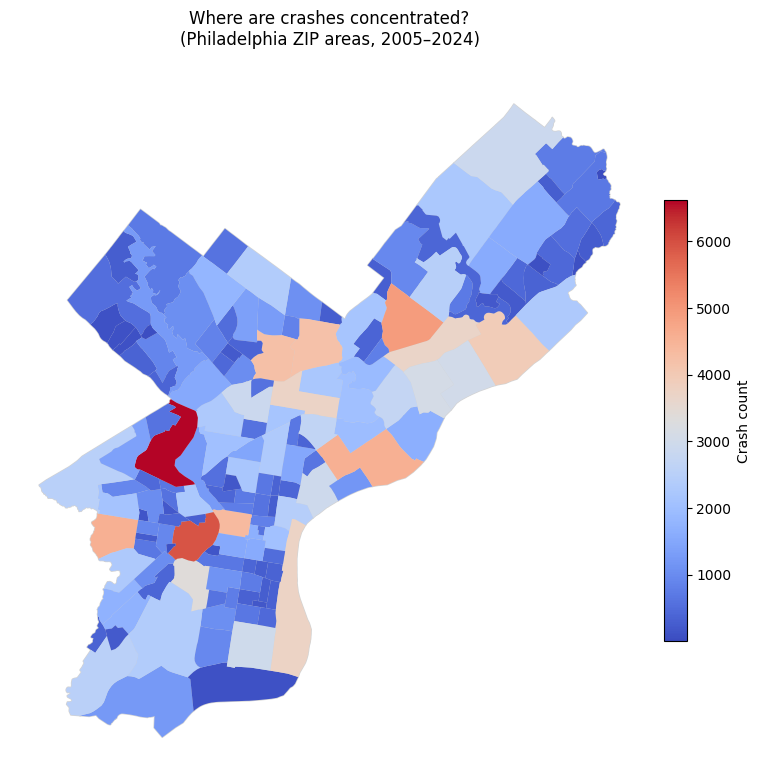

In [4]:
# spatial join: crashes -> zip polygons
zjoin = gpd.sjoin(philly_zip, phil_crashes_gdf, how='left', predicate='contains')

# dissolve by zip and count CRN values
zip_counts = zjoin.dissolve(by='listname', aggfunc={'CRN': 'count'})

zip_counts = zip_counts.rename(columns={'CRN': 'crash_count'})

fig, ax = plt.subplots(figsize=(8,8))

philly_zip.plot(ax=ax, color='white', edgecolor='lightgray')

zip_counts.plot(
    ax=ax,
    column='crash_count',
    cmap='coolwarm',   # blue low -> red high
    legend=True,
    legend_kwds={'shrink': 0.6, 'label': 'Crash count', 'pad': 0.02}
)

ax.set_title("Where are crashes concentrated?\n(Philadelphia ZIP areas, 2005–2024)", pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

While the previous map shows the precise locations of individual crashes, it can be difficult to identify broader geographic patterns when thousands of points overlap across the city. Aggregating crashes by ZIP code helps reveal where incidents are most concentrated across Philadelphia.

Several ZIP codes in and around Center City record the highest total number of crashes. This is true because dense, urban neighbourhoods contain a tightly packed street grid, heavy traffic volumes, and many intersections where vehicles, cyclists, and pedestrians interact frequently. These conditions increase the number of potential conflict points, leading to more incidents overall.

However, a higher number of crashes does not necessarily imply more severe outcomes. In dense areas, traffic tends to move more slowly due to congestion, traffic lights, and frequent intersections. While minor collisions may occur more often in these environments, lower speeds typically reduce the likelihood of fatal outcomes.

In contrast, many of the most severe crashes occur on large arterial roads where vehicles travel at higher speeds and traffic flows more continuously. These wide corridors carry large volumes of vehicles and often combine fast-moving traffic with turning movements and pedestrian crossings. As a result, while dense neighbourhoods may experience more incidents overall, the most dangerous crashes frequently occur on major roadways such as Roosevelt Boulevard and other high-speed corridors across the city.

## How are crashes and fatalities distributed over time in Philadelphia?

We have observed where crashes are most likely to occur, and now we will aim to look at how the number of crashes changes over the period of the whole day, and see if they are correlated in any way to the distribution of fatalities.

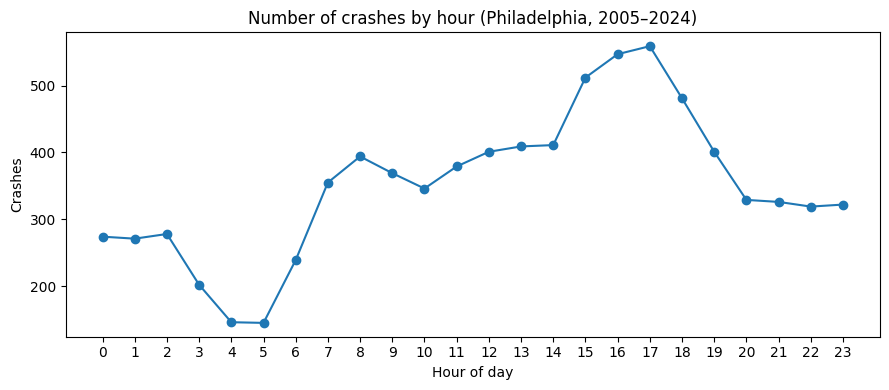

In [31]:
plt.figure(figsize=(9,4))

plt.plot(hour.index, hour['crashes'], marker='o')

plt.title("Number of crashes by hour (Philadelphia, 2005–2024)")
plt.xlabel("Hour of day")
plt.ylabel("Crashes")

plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

The hourly patterns reveal an important distinction between the frequency of crashes and their severity. The total number of crashes rises sharply during the daytime and peaks in the late afternoon, around the evening commuting period between roughly 3 PM and 6 PM. These hours correspond to the highest traffic volumes as people travel to and from work, increasing the number of potential interactions between vehicles.

However, we can see that during the night and early morning, the number of crashes per hour is relatively stable, mostly ranging from 200-300 over the whole 20 year period, with very little crashes having happened around 4 to 5 am in the morning. This reflects the much lower traffic volumes during these hours, when far fewer vehicles are on the road compared with the daytime commuting periods, even though the crashes that do occur may be more severe, which we will observe now.

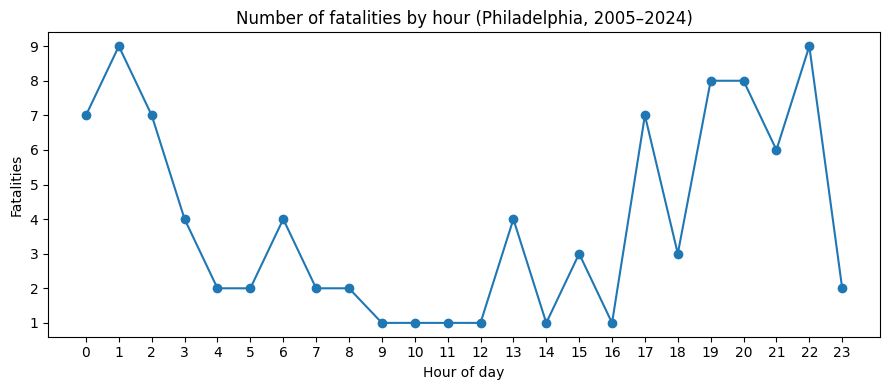

In [32]:
# fatalities by hour
plt.figure(figsize=(9,4))
plt.plot(hour.index, hour['fatalities'], marker='o')

plt.title("Number of fatalities by hour (Philadelphia, 2005–2024)")
plt.xlabel("Hour of day")
plt.ylabel("Fatalities")

plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

When first observing the graph of fatalities by hour, we can see that it follows a very different pattern from the earlier crash distribution, appearing almost like a mirrored version of the original graph.

Fatalities are most concentrated during late-night and evening hours. The highest counts occur around 1 AM and 10 PM, with several other elevated values between 7 PM and midnight. These hours correspond to periods when traffic volumes are lower, but factors such as reduced visibility, driver fatigue, and impaired driving may contribute to the higher severity of crashes during these times.

In contrast, the middle of the day shows relatively few fatalities, particularly between 9 AM and noon, where the counts remain close to one fatality per hour across the entire dataset. This suggests that although crashes are more common during daytime traffic periods, they are less likely to result in fatal outcomes. Congestion, traffic lights, and lower average speeds likely reduce the severity of collisions during these hours.

Combining the insights from the two graphs, a clear pattern emerges: while most crashes occur during the daytime when traffic volumes are highest, fatal crashes are more concentrated during nighttime hours, when vehicles are able to travel at higher speeds and risky driving conditions are more likely.

## Roosevelt Boulevard: Philadelphia’s most dangerous road

Now we will take a deeper dive into what was considered Philadelphia's most dangerous road, testing the claims made by The Philadelphia Tribune which stated that "between 2011 and 2015, 13 percent of the city’s traffic fatalities" have happened on the boulevard, with "pedestrians ma(king) up one-third of those killed on the 12-lane road."

In [33]:
BUFFER_FT = 100
CRS_FEET = 2272

# 1) Find Roosevelt BLVD segments + Roosevelt ramps
rb_main = streets[
    (streets["st_name"].fillna("").str.upper().str.strip() == "ROOSEVELT") &
    (streets["st_type"].fillna("").str.upper().str.strip() == "BLVD")
].copy()

rb_ramps = streets[
    (streets["st_name"].fillna("").str.upper().str.contains("ROOSEVELT", na=False)) &
    (streets["st_type"].fillna("").str.upper().str.strip() == "RAMP")
].copy()

rb = pd.concat([rb_main, rb_ramps], ignore_index=True).to_crs(epsg=CRS_FEET)

# 2) Buffer into a corridor polygon
rb_buf = gpd.GeoDataFrame(geometry=rb.buffer(BUFFER_FT), crs=rb.crs)

# 3) Crashes (2011–2015) projected to feet CRS
city_11_15 = phil_crashes_gdf.query("2011 <= CRASH_YEAR <= 2015").to_crs(epsg=CRS_FEET)
city_fatalities = city_11_15["FATAL_COUNT"].sum()

# 4) Join crashes within corridor + dedupe
rb_joined_11_15 = gpd.sjoin(city_11_15, rb_buf, predicate="within").drop_duplicates("CRN")

# 5) Stats
rb_fatalities_11_15 = rb_joined_11_15["FATAL_COUNT"].sum()
rb_share_11_15 = rb_fatalities_11_15 / city_fatalities

rb_injuries_11_15 = rb_joined_11_15["TOT_INJ_COUNT"].sum()
rb_ped_deaths_11_15 = rb_joined_11_15["PED_DEATH_COUNT"].sum()
rb_ped_share_11_15 = rb_ped_deaths_11_15 / rb_fatalities_11_15

rb_summary = pd.DataFrame({
    "Metric": [
        "Total Number of Crashes", "Fatalities", "Share of city fatalities", "Injuries", "Pedestrian deaths", "Pedestrian share of deaths"
    ],
    "Value": [
        len(rb_joined_11_15),
        int(rb_fatalities_11_15),
        f"{rb_share_11_15:.1%}",
        int(rb_injuries_11_15),
        int(rb_ped_deaths_11_15),
        f"{rb_ped_share_11_15:.1%}"
    ]
})

rb_summary

,Metric,Value
0,Crashes matched,3606
1,Fatalities,65
2,Share of city fatalities,13.8%
3,Injuries,4445
4,Pedestrian deaths,22
5,Pedestrian share of deaths,33.8%


From the above table, we can see that a total of 3606 crashes happened just between 2011 and 2015 on Roosevelt Boulevard. Out of these crashes, there were 65 fatalities. As a proportion of the total number of fatalities that have happened in Philadelphia during this time period, it is 13.8%, which accurately matches the claims made by the Philadelphia Tribune. 

We can additionally see that there were 4445 injuries, which is more than the number of crashes, meaning on average, there was more than one person involved in each of these crashes. A more shocking figure is the number of pedestrian deaths, with there being 22 fatalities over the four year period, and indeed, the pedestrian share of deaths along Roosevelt Boulevard is 33.8%, matching the claims made by the article once again. 

In response to these shocking figures, Philadelphia decided to implement their "Vision Zero" action plan, with the goal of "reduc(ing) Philadelphia traffic deaths to zero by 2030." (Philadelphia Tribune). To achieve this, in June 2020, the government installed speed safety cameras along ten dangerous stretches of highway on Roosevelt Blvd, the effects of which we will see below. 

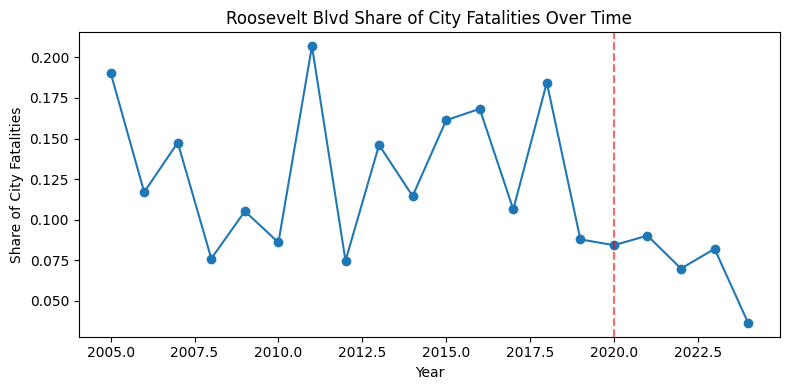

In [11]:
# ------------------------------------------------------------
# Roosevelt Blvd share of city fatalities over time
# Uses rb_buf built above
# ------------------------------------------------------------

def corridor_fatal_share_by_year(all_crashes_feet, corridor_buf):
    years = sorted(all_crashes_feet["CRASH_YEAR"].dropna().unique())
    rows = []
    for y in years:
        sub = all_crashes_feet[all_crashes_feet["CRASH_YEAR"] == y]
        city_fatal = sub["FATAL_COUNT"].sum()
        j = gpd.sjoin(sub, corridor_buf, predicate="within").drop_duplicates("CRN")
        corr_fatal = j["FATAL_COUNT"].sum()
        share = corr_fatal / city_fatal if city_fatal else np.nan
        rows.append([y, corr_fatal, city_fatal, share])
    return pd.DataFrame(rows, columns=["year", "corr_fatal", "city_fatal", "share"])

all_crashes = phil_crashes_gdf.to_crs(epsg=CRS_FEET)

rb_year_df = corridor_fatal_share_by_year(all_crashes, rb_buf)

plt.figure(figsize=(8,4))
plt.plot(rb_year_df["year"], rb_year_df["share"], marker="o")
plt.axvline(2020, linestyle="--", color="red", alpha=0.6)  # June 2020 cameras (year marker)
plt.title("Roosevelt Blvd Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

The figure shows the share of all Philadelphia traffic fatalities that occurred on Roosevelt Boulevard each year. For much of the period before 2020, the boulevard consistently accounted for a substantial proportion of the city’s traffic deaths. In several years it represented more than 15 percent of all fatalities, and in some years exceeded 20 percent, reinforcing its reputation as one of the most dangerous roads in Philadelphia.

The dashed vertical line marks June 2020, when automated speed enforcement cameras were introduced along several segments of Roosevelt Boulevard as part of Philadelphia’s Vision Zero campaign. 

Following the introduction of automated speed enforcement, we can see that the boulevard’s share of citywide fatalities declined significantly. While yearly values continued to fluctuate slightly, the proportion of fatalities occurring on Roosevelt Boulevard remains noticeably lower in the years after 2020 compared with many earlier years in the dataset, with a significant drop in recent years, with the share of city fatalities dropping well below 2.5%.

Reports from the [Philadelphia Parking Authority](https://philapark.org/speed-cameras/) support this pattern. According to the agency, speeding tickets on Roosevelt Boulevard have fallen by 93 percent since the cameras were installed, while fatal and serious injury crashes have decreased by 21 percent and pedestrian-involved crashes have dropped by 50 percent. The apparent reduction in the boulevard’s share of city fatalities after 2020 is therefore consistent with the improvements reported following the introduction of automated speed enforcement.

The perceived success of the program led Pennsylvania legislators to make the camera pilot permanent and allow the city to expand automated speed enforcement to additional roadways. In 2023, the program was extended to several new roads, including sections of Route 611, which covers much of Broad Street, which we will explore next.

In [37]:
# ------------------------------------------------------------
# Broad Street: corridor buffer stats (2011–2015)
# ------------------------------------------------------------

broad = streets[
    (streets["st_name"].fillna("").str.upper().str.strip() == "BROAD") &
    (streets["st_type"].fillna("").str.upper().str.strip() == "ST")
].copy().to_crs(epsg=CRS_FEET)

broad_buf = gpd.GeoDataFrame(geometry=broad.buffer(BUFFER_FT), crs=broad.crs)

city_11_15 = phil_crashes_gdf.query("2011 <= CRASH_YEAR <= 2015").to_crs(epsg=CRS_FEET)
city_fatalities = city_11_15["FATAL_COUNT"].sum()

broad_joined_11_15 = gpd.sjoin(city_11_15, broad_buf, predicate="within").drop_duplicates("CRN")

broad_fatalities_11_15 = broad_joined_11_15["FATAL_COUNT"].sum()
broad_share_11_15 = broad_fatalities_11_15 / city_fatalities if city_fatalities else np.nan

broad_injuries_11_15 = broad_joined_11_15["TOT_INJ_COUNT"].sum()
broad_ped_deaths_11_15 = broad_joined_11_15["PED_DEATH_COUNT"].sum()
broad_ped_share_11_15 = broad_ped_deaths_11_15 / broad_fatalities_11_15 if broad_fatalities_11_15 else np.nan

broad_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Crashes", "Fatalities", "Share of city fatalities", "Injuries", "Pedestrian deaths", "Pedestrian share of deaths",
        ],
        "Broad Street (2011–2015)": [
            f"{len(broad_joined_11_15):,}",
            f"{int(broad_fatalities_11_15):,}",
            f"{broad_share_11_15:.1%}",
            f"{int(broad_injuries_11_15):,}",
            f"{int(broad_ped_deaths_11_15):,}",
            f"{broad_ped_share_11_15:.1%}",
        ],
    }
)

# show as a clean table in notebooks
broad_summary.style.hide(axis="index")

Metric,Broad Street (2011–2015)
Total Crashes,"2,087"
Fatalities,24
Share of city fatalities,5.1%
Injuries,"2,284"
Pedestrian deaths,13
Pedestrian share of deaths,54.2%


Broad Street shows a different pattern of crash outcomes compared with Roosevelt Boulevard. Between 2011 and 2015, Broad Street recorded fewer crashes and fatalities overall, with 24 deaths and a 5.1 percent share of city fatalities, compared with 65 deaths and a 13.8 percent share on Roosevelt Boulevard. However, a much larger proportion of fatalities on Broad Street involved pedestrians. Over half of all deaths on Broad Street (54.2 percent) were pedestrians, compared with 33.8 percent on Roosevelt Boulevard. This highlights the different roles these roads play within the city. Roosevelt Boulevard functions as a wide, high-speed arterial corridor designed primarily for vehicle movement, whereas Broad Street runs through dense urban neighbourhoods with frequent pedestrian crossings and intersections.

This pattern is consistent with broader findings about dangerous roads in Philadelphia. According to an analysis of PennDOT crash data reported by Wapner Newman, a seven-mile stretch of Broad Street ranked among Pennsylvania’s ten deadliest road segments, with multiple fatal crashes recorded between 2015 and 2017. While Broad Street may not account for as many total fatalities as Roosevelt Boulevard, the higher share of pedestrian deaths reflects the greater interaction between vehicles and pedestrians along one of the city’s busiest urban roadways.

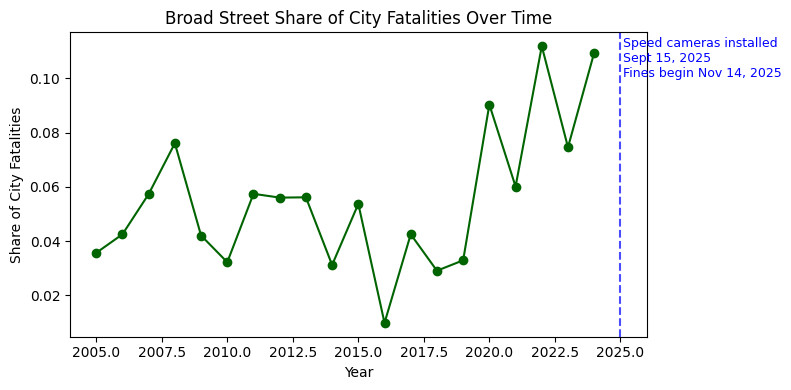

In [18]:
# ------------------------------------------------------------
# Broad Street share of city fatalities over time
# ------------------------------------------------------------

broad_year_results = []

for y in years:
    subset = all_crashes[all_crashes['CRASH_YEAR'] == y]
    b_fatal, city_fatal, share = corridor_stats(subset, broad_buf)
    broad_year_results.append([y, b_fatal, city_fatal, share])

broad_year_df = pd.DataFrame(broad_year_results, columns=['year','broad_fatal','city_fatal','share'])

plt.figure(figsize=(8,4))

plt.plot(broad_year_df['year'],
         broad_year_df['share'],
         marker='o',
         color='darkgreen',
         label='Broad Street share of city fatalities')

# vertical line for enforcement policy
plt.axvline(2025, linestyle='--', color='blue', alpha=0.7)

# annotation explaining the policy
plt.text(2025.1,
         broad_year_df['share'].max()*0.9,
         "Speed cameras installed\nSept 15, 2025\nFines begin Nov 14, 2025",
         fontsize=9,
         color='blue')

plt.title("Broad Street Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

https://6abc.com/post/broad-street-speed-cameras-activated-philadelphia-drivers-face-100-ticket/18154437/

The figure above shows the share of all Philadelphia traffic fatalities occurring on Broad Street over time. For much of the early and mid-2000s, Broad Street consistently accounted for between 3 and 8 percent of the city’s annual fatalities. While this share fluctuated from year to year, the overall values remained noticeably lower than those observed on Roosevelt Boulevard, reflecting the smaller number of total fatal crashes recorded along the corridor.

However, in more recent years the share increased noticeably, with several years after 2020 exceeding 8–11 percent of citywide fatalities. This upward trend  explains why Broad Street had become a growing focus of traffic safety efforts within Philadelphia. As one of the city’s busiest north–south corridors passing through center city, the road experiences heavy vehicle traffic alongside significant pedestrian and cyclist activity, creating conditions where severe crashes can occur.

In response to these concerns, the city introduced automated speed enforcement along Broad Street, with cameras installed at 15 intersections along North and South Broad Street. According to a report by [6abc Philadelphia](https://6abc.com/post/broad-street-speed-cameras-activated-philadelphia-drivers-face-100-ticket/18154437/), the cameras became fully operational in November 2025, after a 60-day warning period, with drivers caught exceeding the speed limit by more than 11 mph receiving fines starting at $100. According to the report, officials hope that the cameras will reduce speeding and improve safety in the same way that automated enforcement did on Roosevelt Boulevard, where violations dropped dramatically and pedestrian crashes declined significantly.

Although the data shown in the figure predates the full implementation of the Broad Street camera program, the trend highlights why the road became a priority for intervention. By targeting high-risk roads where fatalities represent a growing share of citywide incidents, automated speed enforcement is able to potentially reduce dangerous driving behaviour and improve safety for both drivers and pedestrians.

## Conclusion
